<a href="https://colab.research.google.com/github/csorty/car/blob/main/paint_dots.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

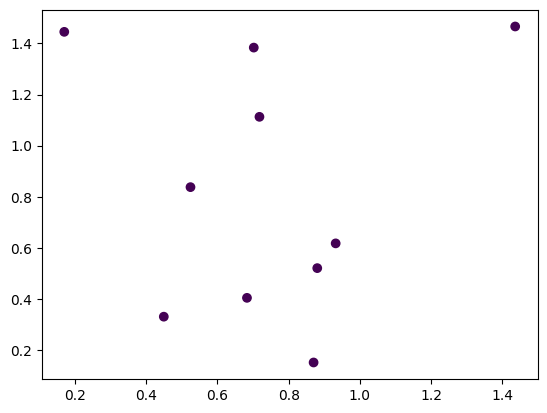

In [18]:
import random
import pygame
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
import sys

class Point:
    def __init__(self, x, y):
        self.x = x
        self.y = y
        self.cluster = None

def generate_points(centers_count = 3, points_count=10):
    points= []
    for _ in range(centers_count):
      centerX, centerY=random.random(), random.random()
      for _ in range(points_count):
          points.append(
            Point(
                random.gauss(centerX, 0.5), random.gauss(centerY, 0.5)
                    )
                )
      return points

points = generate_points()
x, y =[], []
for p in points:
  x.append(p.x)
  y.append(p.y)

dbscan = DBSCAN(eps = 40)
dbscan.fit([[p.x, p.y] for p in points])
labels = dbscan.labels_

plt.scatter(x, y, c = labels)
plt.show()

#my_pygame()


def generate_colors(n: int):
  colors =[]
  for _ in range(n):
    colors.append((
        random.randint(0, 255),
        random.randint(0, 255),
        random.randint(0, 255)
    ))
  return colors

def my_pygame():
    points = []
    pygame.init()
    screen = pygame.display.set_mode((600, 400), pygame.RESIZABLE)
    screen.fill("white")
    pygame.display.flip()

    while True:

      for event in pygame.event.get():
        if event.type == pygame.QUIT:
            pygame.quit()
            exit()

        if event.type == pygame.WINDOWSIZE:
            screen.fill("white")
            for point in points:
                pygame.draw.circle(screen, "black", (int(point.x), int(point.y)), 10)

        if event.type == pygame.MOUSEBUTTONDOWN:
            if event.button == 1:
                points.append(Point(*event.pos))
                pygame.draw.circle(screen, "black", event.pos, 10)

        if event.type == pygame.KEYDOWN:
            if event.key == pygame.K_r:
                dbscan = DBSCAN(eps=40)
                dbscan.fit([[p.x, p.y] for p in points])
                labels = dbscan.labels_

                colors = generate_colors(max(labels) + 1)
                screen.fill("white")
                for i, p in enumerate(points):
                    p.cluster = labels[i]
                    pygame.draw.circle(screen, colors[p.cluster], (int(p.x), int(p.y)), 10)

                print(labels)

    pygame.display.update()

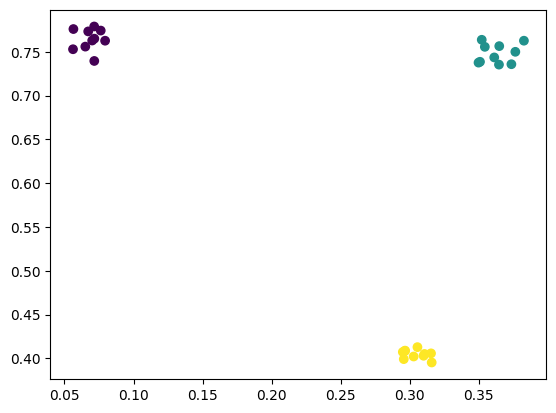

In [13]:
import pygame
import random
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import DBSCAN

#это всё надо чтобы реализовать как-то класс, прошлую верстю можно было оставить без класса
def main():
    points = generate_points()
    pointXY = np.array([[p.x, p.y] for p in points])            #(points[:,0], points[:,1]) #скобки первое двоеточие то есть идет по всем второе число показываает\
    #позицию во втором столбце. Первый поинтс выведет весь столбец икс

    dbscan = DBSCAN(eps = 0.1) #берет точку и смотрит рядос с ней, если находит, то ставит флажок
    #dbscan.fit(pointXY)
    #labels = dbscan.labels_

    labels = dbscan.fit_predict(pointXY)
    plt.scatter(pointXY[:,0], pointXY[:,1], c = labels)
    #print(pointXY)
    plt.show()


class Point:
    def __init__(self, x, y):
        self.x = x
        self.y = y
        self.cluster = None

def generate_points(count_of_centers = 3, count_of_point = 10):
       #генерируем функцию и пишем к ней параметры, значение в них это параметр по умолчанию
    points = []
    for _ in range(count_of_centers):
        centerX, centerY = random.random(), random.random()
        for _ in range(count_of_point):
            points.append(Point(
                random.gauss(centerX, 0.01),
                random.gauss(centerY, 0.01)
            ))
    return points


def my_pygame():
    pygame.init()
    screen = pygame.display.set_mode((600,400))
    while True:
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                pygame.quit()
                exit()



if __name__== '__main__':
    main()